In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the SMS spam dataset
df = pd.read_csv("spam.csv", encoding="latin1")

# Display the first five records
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
# Inspect the dataset structure

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())



Dataset Shape: (5572, 5)

Column Names:
['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

Missing Values:
v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

Duplicate Rows: 403


In [5]:
# Remove unnecessary empty columns

df = df[["v1", "v2"]]

# Rename columns for clarity
df.columns = ["Label", "Message"]

# Remove duplicate messages
df = df.drop_duplicates().reset_index(drop=True)

print("Cleaned Dataset Shape:", df.shape)
df.head()

Cleaned Dataset Shape: (5169, 2)


,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### Class Distribution

The distribution of spam and ham messages is analyzed to understand the balance between the two classes before building the classification models.

In [6]:
# Analyze class distribution

class_counts = df["Label"].value_counts()
class_percentages = df["Label"].value_counts(normalize=True) * 100

class_distribution = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages.round(2)
})

class_distribution

,Count,Percentage
Label,,
ham,4516,87.37
spam,653,12.63


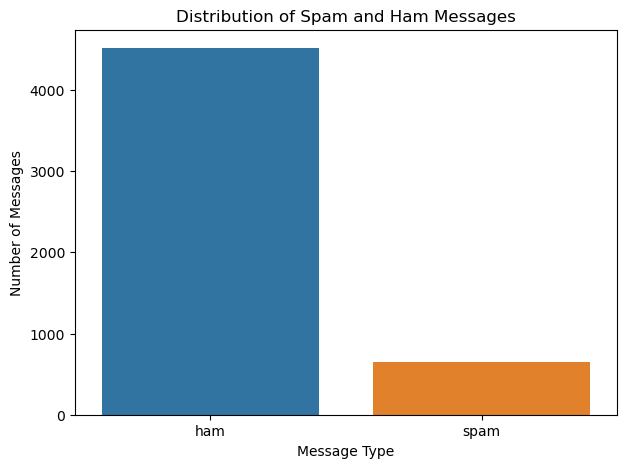

In [7]:
# Visualize class distribution

plt.figure(figsize=(7, 5))

sns.countplot(x="Label", data=df)

plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.show()

### Text Preprocessing

The message text is cleaned before feature extraction. The preprocessing includes converting text to lowercase, removing punctuation and non-alphabetic characters, and removing common English stopwords.

In [8]:
# Import required libraries for text preprocessing

import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stop_words = set(ENGLISH_STOP_WORDS)

def preprocess_text(text):
    # Convert text to lowercase
    text = text.lower()
    
    # Remove punctuation and non-alphabetic characters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    
    # Split text into words
    words = text.split()
    
    # Remove stopwords
    words = [word for word in words if word not in stop_words]
    
    # Join words back into a sentence
    return " ".join(words)

# Apply preprocessing
df["Clean_Message"] = df["Message"].apply(preprocess_text)

# Display original and cleaned messages
df[["Message", "Clean_Message"]].head(10)

,Message,Clean_Message
0,"Go until jurong point, crazy.. Available only ...",jurong point crazy available bugis n great wor...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c say
4,"Nah I don't think he goes to usf, he lives aro...",nah don t think goes usf lives
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darling s week s word d like fun t...
6,Even my brother is not like to speak with me. ...,brother like speak treat like aids patent
7,As per your request 'Melle Melle (Oru Minnamin...,request melle melle oru minnaminunginte nurung...
8,WINNER!! As a valued network customer you have...,winner valued network customer selected receiv...
9,Had your mobile 11 months or more? U R entitle...,mobile months u r entitled update latest colou...


### TF-IDF Vectorization



In [9]:
# Import TF-IDF Vectorizer

from sklearn.feature_extraction.text import TfidfVectorizer

# Create the TF-IDF vectorizer
tfidf = TfidfVectorizer()

# Transform the cleaned messages into TF-IDF features
X = tfidf.fit_transform(df["Clean_Message"])

# Target variable
y = df["Label"]

print("TF-IDF Matrix Shape:", X.shape)

TF-IDF Matrix Shape: (5169, 7414)



### Train-Test Split


In [10]:
# Import train_test_split

from sklearn.model_selection import train_test_split

# Split the TF-IDF features and target variable
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (4135, 7414)
Testing Set Shape: (1034, 7414)


### Multinomial Naive Bayes

In [11]:
# Train the Multinomial Naive Bayes classifier

from sklearn.naive_bayes import MultinomialNB

# Create the model
nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train, y_train)

# Predict the test data
nb_predictions = nb_model.predict(X_test)

print("Multinomial Naive Bayes model trained successfully.")

Multinomial Naive Bayes model trained successfully.


### Logistic Regression



In [12]:
# Train the Logistic Regression classifier

from sklearn.linear_model import LogisticRegression

# Create the model
lr_model = LogisticRegression(max_iter=1000)

# Train the model
lr_model.fit(X_train, y_train)

# Predict the test data
lr_predictions = lr_model.predict(X_test)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### Model Evaluation

In [13]:
# Import evaluation metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluate Multinomial Naive Bayes
nb_accuracy = accuracy_score(y_test, nb_predictions)
nb_precision = precision_score(y_test, nb_predictions, pos_label="spam")
nb_recall = recall_score(y_test, nb_predictions, pos_label="spam")
nb_f1 = f1_score(y_test, nb_predictions, pos_label="spam")

# Evaluate Logistic Regression
lr_accuracy = accuracy_score(y_test, lr_predictions)
lr_precision = precision_score(y_test, lr_predictions, pos_label="spam")
lr_recall = recall_score(y_test, lr_predictions, pos_label="spam")
lr_f1 = f1_score(y_test, lr_predictions, pos_label="spam")

# Create comparison table
results = pd.DataFrame({
    "Model": ["Multinomial Naive Bayes", "Logistic Regression"],
    "Accuracy": [nb_accuracy, lr_accuracy],
    "Precision": [nb_precision, lr_precision],
    "Recall": [nb_recall, lr_recall],
    "F1-Score": [nb_f1, lr_f1]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1-Score
0,Multinomial Naive Bayes,0.9691,1.0000,0.7557,0.8609
1,Logistic Regression,0.9497,0.9877,0.6107,0.7547


### Confusion Matrix

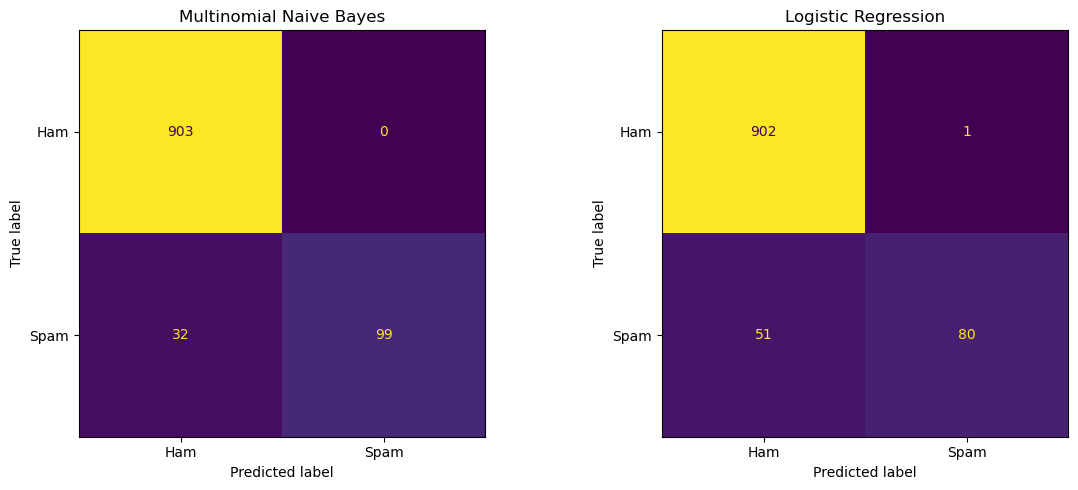

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion matrices
nb_cm = confusion_matrix(y_test, nb_predictions, labels=["ham", "spam"])
lr_cm = confusion_matrix(y_test, lr_predictions, labels=["ham", "spam"])

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix=nb_cm,
    display_labels=["Ham", "Spam"]
).plot(ax=axes[0], colorbar=False)

axes[0].set_title("Multinomial Naive Bayes")

ConfusionMatrixDisplay(
    confusion_matrix=lr_cm,
    display_labels=["Ham", "Spam"]
).plot(ax=axes[1], colorbar=False)

axes[1].set_title("Logistic Regression")

plt.tight_layout()
plt.show()

### Why Recall is Important for Spam Detection

Recall measures the proportion of actual spam messages that are correctly identified as spam.

In spam detection, high recall is important because a false negative occurs when an actual spam message is classified as ham. A low recall means more spam messages may reach the user's inbox.

Therefore, recall is an important metric for measuring how effectively the classifier detects actual spam messages.

### Bonus: WordCloud Visualization

WordClouds provide a visual representation of frequently occurring words in spam and ham messages. They help identify common words associated with each message category.

In [15]:
pip install wordcloud

  Obtaining dependency information for wordcloud from https://files.pythonhosted.org/packages/45/70/0041966d469dec79036ad3962b83b007004b842531ee7c41bdba61310eb6/wordcloud-1.9.6-cp311-cp311-win_amd64.whl.metadata
   ---------------------------------------- 0.0/306.1 kB ? eta -:--:--
   ---- ----------------------------------- 30.7/306.1 kB 1.3 MB/s eta 0:00:01
   ------------ --------------------------- 92.2/306.1 kB 1.3 MB/s eta 0:00:01
   ------------- ------------------------ 112.6/306.1 kB 930.9 kB/s eta 0:00:01
   ---------------------- ----------------- 174.1/306.1 kB 1.0 MB/s eta 0:00:01
   ------------------------------ --------- 235.5/306.1 kB 1.1 MB/s eta 0:00:01
   -------------------------------------- - 297.0/306.1 kB 1.1 MB/s eta 0:00:01
   ---------------------------------------- 306.1/306.1 kB 1.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [16]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

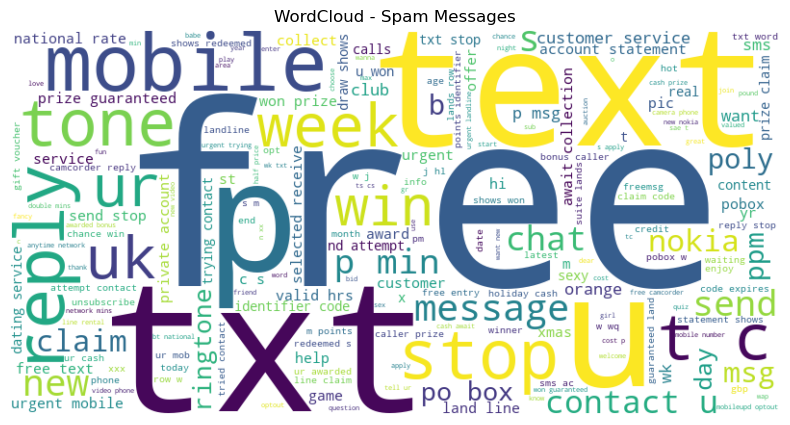

In [17]:
spam_text = " ".join(df[df["Label"] == "spam"]["Clean_Message"])

spam_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(spam_text)

plt.figure(figsize=(10, 5))
plt.imshow(spam_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud - Spam Messages")
plt.show()

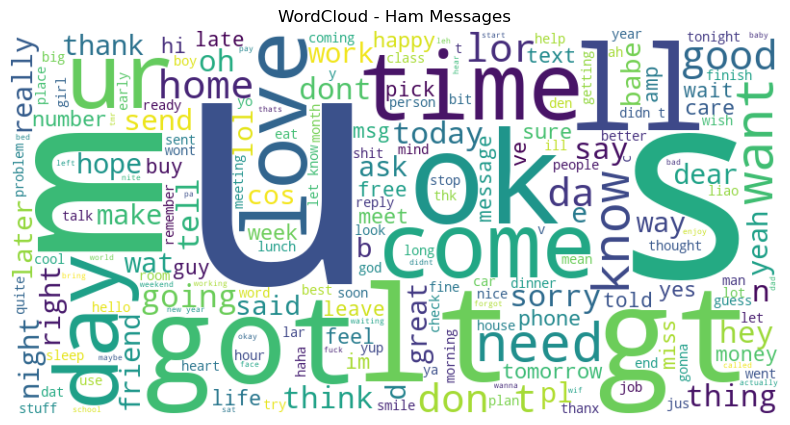

In [18]:
ham_text = " ".join(df[df["Label"] == "ham"]["Clean_Message"])

ham_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(ham_text)

plt.figure(figsize=(10, 5))
plt.imshow(ham_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud - Ham Messages")
plt.show()